In [1]:
!pip install librosa pydub scikit-learn joblib

import numpy as np
import os
import librosa
from pydub import AudioSegment
import matplotlib.pyplot as plt
import joblib

from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
DATA_PATH = "/content/drive/MyDrive/genres_original"

In [4]:
import os
print(os.listdir(DATA_PATH))

['rock', 'country', 'hiphop', 'pop', 'jazz', 'metal', 'disco', 'reggae', 'classical', 'blues']


In [5]:
# Function for generate spectorgrams
def generate_spectrogram(file_path):
    try:
        audio = AudioSegment.from_file(file_path)

        target_ms = 30 * 1000

        if len(audio) < target_ms:
            audio = audio * (target_ms // len(audio) + 1)

        if len(audio) > target_ms:
            audio = audio[:target_ms]

        audio.export("temp.wav", format="wav")

        # Fixed duration
        y, sr = librosa.load("temp.wav", duration=30)

        mel = librosa.feature.melspectrogram(
            y=y,
            sr=sr,
            n_fft=1024,
            hop_length=512
        )

        mel = librosa.power_to_db(mel, ref=np.max)


        mel = librosa.util.fix_length(mel, size=1280, axis=1)

        # normalize
        mel = (mel - mel.min()) / (mel.max() - mel.min())

        return mel

    except:
        return None

In [6]:
DATA_PATH = "/content/drive/MyDrive/genres_original"

GENRES = sorted(os.listdir(DATA_PATH))

X = []
y = []

for label, genre in enumerate(GENRES):
    folder = os.path.join(DATA_PATH, genre)

    print("Processing:", genre)

    for file in os.listdir(folder):
        file_path = os.path.join(folder, file)

        spec = generate_spectrogram(file_path)

        if spec is not None:
            X.append(spec.flatten())
            y.append(label)

X = np.array(X)
y = np.array(y)

print("Dataset shape:", X.shape)

Processing: blues
Processing: classical
Processing: country
Processing: disco
Processing: hiphop
Processing: jazz
Processing: metal
Processing: pop
Processing: reggae
Processing: rock
Dataset shape: (999, 163840)


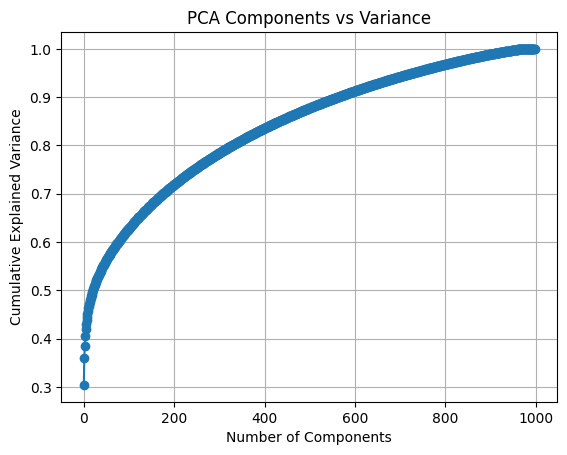

In [7]:
 # Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit PCA (all components)
pca = PCA()
pca.fit(X_scaled)

# Get explained variance
explained_var = pca.explained_variance_ratio_
cum_var = np.cumsum(explained_var)

# Plot graph
plt.figure()
plt.plot(cum_var, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Components vs Variance")
plt.grid()
plt.show()

In [8]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# PCA
pca = PCA(n_components=0.92)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# SVM
svm= SVC(kernel='rbf', C=1, gamma='scale')
svm.fit(X_train_pca, y_train)

# Accuracy
print("Train acc:", svm.score(X_train_pca, y_train))
print("Test acc:", svm.score(X_test_pca, y_test))

Train acc: 0.9161451814768461
Test acc: 0.48


In [9]:
y_pred = svm.predict(X_test_pca)

print(confusion_matrix(y_test, y_pred))

[[ 9  0  0  2  2  0  3  0  0  5]
 [ 0 10  0  0  2  0  0  0  0  0]
 [ 2  1  9  2  1  3  0  0  0  6]
 [ 0  0  0 12  1  0  3  3  0  3]
 [ 0  0  0  4 10  0  0  0  1  0]
 [ 7  2  0  4  1  9  0  1  2  1]
 [ 0  0  0  0  0  0 16  0  0  2]
 [ 0  0  3  2  0  0  0 13  0  1]
 [ 6  0  1  1  6  5  1  1  1  0]
 [ 0  0  5  3  0  2  1  1  1  7]]


In [10]:
y_pred = svm.predict(X_test_pca)

print(classification_report(y_test, y_pred, target_names=GENRES))

              precision    recall  f1-score   support

       blues       0.38      0.43      0.40        21
   classical       0.77      0.83      0.80        12
     country       0.50      0.38      0.43        24
       disco       0.40      0.55      0.46        22
      hiphop       0.43      0.67      0.53        15
        jazz       0.47      0.33      0.39        27
       metal       0.67      0.89      0.76        18
         pop       0.68      0.68      0.68        19
      reggae       0.20      0.05      0.07        22
        rock       0.28      0.35      0.31        20

    accuracy                           0.48       200
   macro avg       0.48      0.52      0.48       200
weighted avg       0.46      0.48      0.46       200



In [11]:
joblib.dump(svm, "svm_model.pkl")
joblib.dump(pca, "pca_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(GENRES, "labels.pkl")

print("Models saved!")

Models saved!


In [16]:
from google.colab import files

files.download("svm_model.pkl")
files.download("pca_model.pkl")
files.download("scaler.pkl")
files.download("labels.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
def predict(file_path):
    spec = generate_spectrogram(file_path)

    if spec is None:
        return "Invalid audio"

    x = spec.flatten().reshape(1, -1)
    x = scaler.transform(x)
    x = pca.transform(x)

    pred = svm.predict(x)[0]

    return GENRES[pred]